# Notebook 4 — NLP Analysis
## COSC 2671 Social Media and Network Analysis — Assignment 2
### "Who Drives Open-Source AI? Network Centrality and Discourse Analysis on GitHub ML Repositories"

**Goal:** Score sentiment with VADER, model topics with BERTopic, and correlate centrality with sentiment to answer the core research question.

**Inputs:**  
- `data/processed/{safe_name}_clean.csv`  
- `data/processed/all_centrality.pkl` (from Notebook 3)

**Outputs:** sentiment CSVs, topic model results, Spearman correlation table, figures

**Success Criteria:**  
- SC4: BERTopic ≥ 5 coherent topics per repo  
- SC5: Mann-Whitney U p < 0.05 (open vs closed issue sentiment)  
- SC6: Spearman rho significant (centrality vs sentiment) — HD extension

## Cell 2 — Set Working Directory

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = next(
    path.parent.parent
    for path in Path.home().rglob("data/raw")
    if (
        (path.parent / "processed").is_dir()
        and (path.parent.parent / "notebooks").is_dir()
        and (path.parent.parent / "outputs").is_dir()
    )
)

os.chdir(PROJECT_ROOT)

print(f"Working directory: {os.getcwd()}")
print(f"data/processed exists: {os.path.exists('data/processed')}")
print(f"outputs/tables exists:  {os.path.exists('outputs/tables')}")
print(f"outputs/figures exists: {os.path.exists('outputs/figures')}")
print(f"all_centrality.pkl exists: {os.path.exists('data/processed/all_centrality.pkl')}")

Working directory: /Users/rob/Desktop/2026/social/SMNA2026-A2-github-networks
data/processed exists: True
outputs/tables exists:  True
outputs/figures exists: True
all_centrality.pkl exists: True


## Cell 3 — Imports, Constants, SAFE_NAMES

In [2]:
import warnings
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

warnings.filterwarnings("ignore")

# ── Repositories ─────────────────────────────────────────────────────
REPOS = [
    "scikit-learn/scikit-learn",
    "huggingface/transformers",
    "pytorch/pytorch",
    "keras-team/keras",
    "langchain-ai/langchain",
]

SAFE_NAMES = {
    "scikit-learn/scikit-learn": "scikit-learn_scikit-learn",
    "huggingface/transformers":  "huggingface_transformers",
    "pytorch/pytorch":           "pytorch_pytorch",
    "keras-team/keras":          "keras-team_keras",
    "langchain-ai/langchain":    "langchain-ai_langchain",
}

# ── Paths ─────────────────────────────────────────────────────────────
PROCESSED_DIR = "data/processed"
TABLES_DIR    = "outputs/tables"
FIGURES_DIR   = "outputs/figures"

# ── Shared storage (populated across cells) ───────────────────────────
all_sentiment   = {}   # repo → DataFrame with vader scores
all_topics      = {}   # repo → (topic_model, topic_info_df)
sc_results      = {}   # repo → dict of SC check outcomes

print("Imports OK.")
print(f"Repos: {len(REPOS)}")

Imports OK.
Repos: 5


## Cell 4 — Load Centrality Data from Notebook 3

In [3]:
centrality_pkl = f"{PROCESSED_DIR}/all_centrality.pkl"

with open(centrality_pkl, "rb") as f:
    all_centrality = pickle.load(f)

print("Loaded centrality data from Notebook 3:")
for repo, df in all_centrality.items():
    print(f"  {repo}: {len(df):,} users  |  columns: {list(df.columns)}")

Loaded centrality data from Notebook 3:
  scikit-learn/scikit-learn: 769 users  |  columns: ['rank', 'user', 'pagerank', 'betweenness', 'norm_indegree', 'in_degree', 'out_degree', 'composite', 'core_number']
  huggingface/transformers: 948 users  |  columns: ['rank', 'user', 'pagerank', 'betweenness', 'norm_indegree', 'in_degree', 'out_degree', 'composite', 'core_number']
  pytorch/pytorch: 409 users  |  columns: ['rank', 'user', 'pagerank', 'betweenness', 'norm_indegree', 'in_degree', 'out_degree', 'composite', 'core_number']
  keras-team/keras: 758 users  |  columns: ['rank', 'user', 'pagerank', 'betweenness', 'norm_indegree', 'in_degree', 'out_degree', 'composite', 'core_number']
  langchain-ai/langchain: 839 users  |  columns: ['rank', 'user', 'pagerank', 'betweenness', 'norm_indegree', 'in_degree', 'out_degree', 'composite', 'core_number']


## Cell 5 — VADER Sentiment Scoring

In [4]:
def score_sentiment(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add vader_compound, vader_pos, vader_neu, vader_neg columns.
    Scores every row (issues and comments) using clean_text.
    Falls back to empty string if clean_text is NaN.
    """
    analyzer = SentimentIntensityAnalyzer()
    df = df.copy()
    df["clean_text"] = df["clean_text"].fillna("")

    scores = df["clean_text"].apply(lambda t: analyzer.polarity_scores(t))
    df["vader_compound"] = scores.apply(lambda s: s["compound"])
    df["vader_pos"]      = scores.apply(lambda s: s["pos"])
    df["vader_neu"]      = scores.apply(lambda s: s["neu"])
    df["vader_neg"]      = scores.apply(lambda s: s["neg"])

    return df


print("score_sentiment() defined.")
print("Running VADER on all repos — this takes ~1–2 minutes total...")

for repo in REPOS:
    safe     = SAFE_NAMES[repo]
    csv_path = f"{PROCESSED_DIR}/{safe}_clean.csv"
    df       = pd.read_csv(csv_path, low_memory=False)
    df["created_at"] = pd.to_datetime(df["created_at"], utc=True, errors="coerce")

    print(f"\n  {repo}: {len(df):,} rows → scoring...")
    df = score_sentiment(df)
    all_sentiment[repo] = df

    # Save scored CSV
    out_path = f"{PROCESSED_DIR}/{safe}_sentiment.csv"
    df.to_csv(out_path, index=False)
    print(f"  Saved → {out_path}")
    print(f"  Mean compound: {df['vader_compound'].mean():.4f}  "
          f"|  Issues: {(df['type']=='issue').sum():,}  "
          f"|  Comments: {(df['type']=='comment').sum():,}")

print("\n✅ VADER scoring complete.")

score_sentiment() defined.
Running VADER on all repos — this takes ~1–2 minutes total...

  scikit-learn/scikit-learn: 11,469 rows → scoring...
  Saved → data/processed/scikit-learn_scikit-learn_sentiment.csv
  Mean compound: 0.2528  |  Issues: 1,729  |  Comments: 9,740

  huggingface/transformers: 9,073 rows → scoring...
  Saved → data/processed/huggingface_transformers_sentiment.csv
  Mean compound: 0.2678  |  Issues: 1,990  |  Comments: 7,083

  pytorch/pytorch: 5,028 rows → scoring...
  Saved → data/processed/pytorch_pytorch_sentiment.csv
  Mean compound: 0.1065  |  Issues: 1,724  |  Comments: 3,304

  keras-team/keras: 9,324 rows → scoring...
  Saved → data/processed/keras-team_keras_sentiment.csv
  Mean compound: 0.2490  |  Issues: 1,995  |  Comments: 7,329

  langchain-ai/langchain: 7,656 rows → scoring...
  Saved → data/processed/langchain-ai_langchain_sentiment.csv
  Mean compound: 0.1703  |  Issues: 1,993  |  Comments: 5,663

✅ VADER scoring complete.


## Cell 6 — Sentiment Distribution Plots

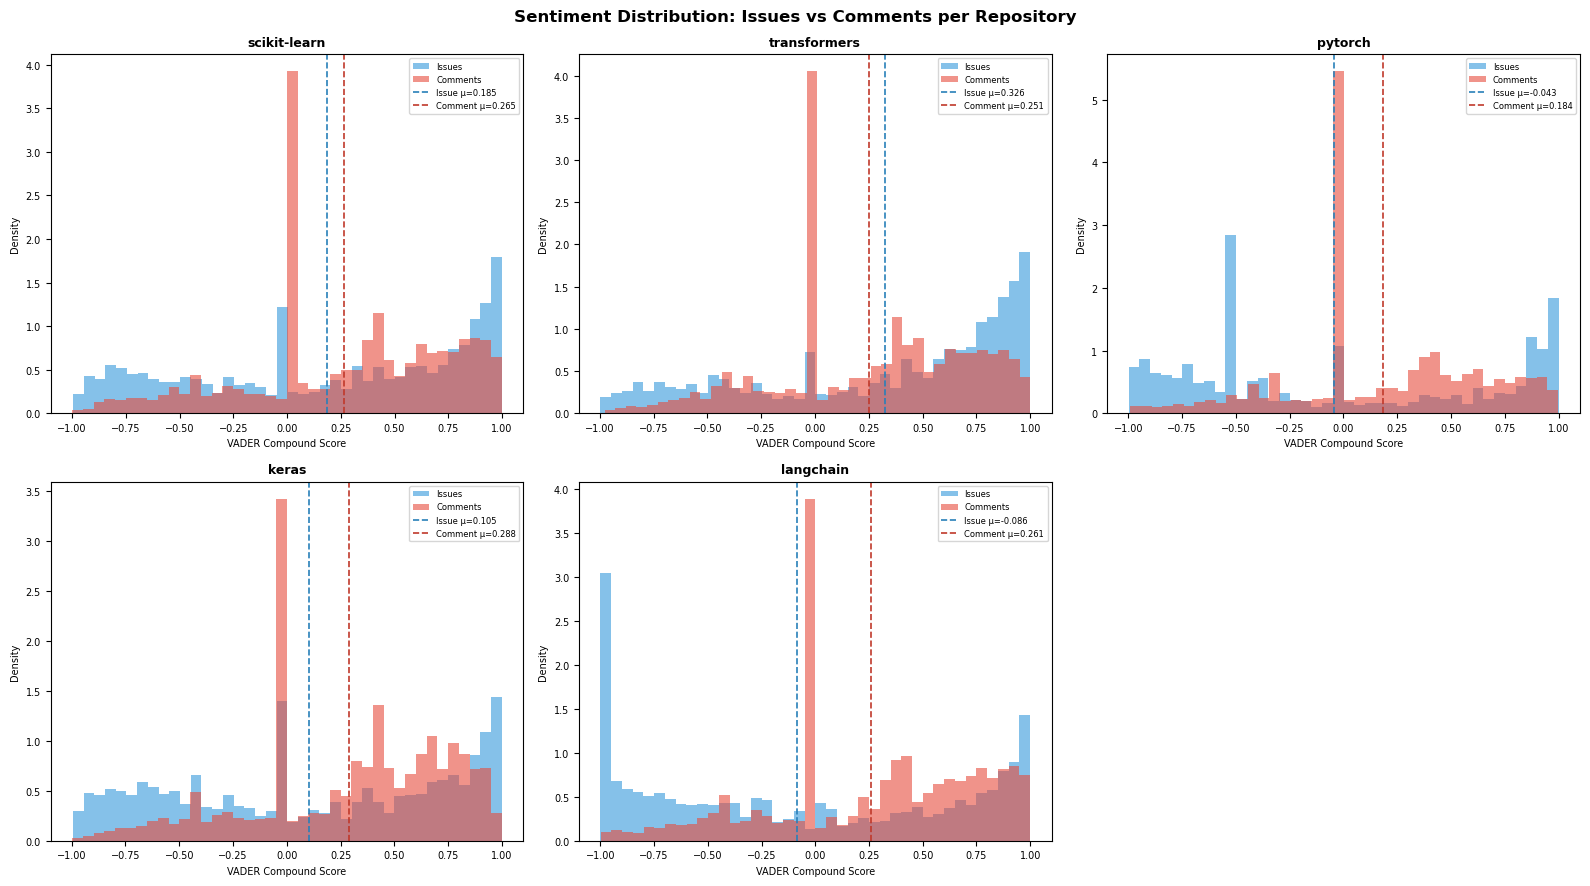

Saved → outputs/figures/sentiment_distribution.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, repo in enumerate(REPOS):
    df  = all_sentiment[repo]
    ax  = axes[i]
    safe = SAFE_NAMES[repo]

    issues   = df[df["type"] == "issue"]["vader_compound"]
    comments = df[df["type"] == "comment"]["vader_compound"]

    ax.hist(issues,   bins=40, alpha=0.6, label="Issues",   color="#3498db", density=True)
    ax.hist(comments, bins=40, alpha=0.6, label="Comments", color="#e74c3c", density=True)
    ax.axvline(issues.mean(),   color="#2980b9", linestyle="--", linewidth=1.2,
               label=f"Issue μ={issues.mean():.3f}")
    ax.axvline(comments.mean(), color="#c0392b", linestyle="--", linewidth=1.2,
               label=f"Comment μ={comments.mean():.3f}")

    ax.set_title(repo.split("/")[1], fontsize=9, fontweight="bold")
    ax.set_xlabel("VADER Compound Score", fontsize=7)
    ax.set_ylabel("Density", fontsize=7)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)

axes[-1].set_visible(False)
plt.suptitle("Sentiment Distribution: Issues vs Comments per Repository",
             fontsize=12, fontweight="bold")
plt.tight_layout()
dist_path = f"{FIGURES_DIR}/sentiment_distribution.png"
plt.savefig(dist_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {dist_path}")

## Cell 7 — Mann-Whitney U Test: Open vs Closed Issues (SC5)

In [6]:
from scipy.stats import mannwhitneyu

print("── SC5: Mann-Whitney U — Open vs Closed Issue Sentiment ──\n")

mw_rows = []

for repo in REPOS:
    df = all_sentiment[repo]

    # Issues only (not comments)
    issues = df[df["type"] == "issue"].copy()
    open_sent   = issues[issues["state"] == "open"]["vader_compound"].dropna()
    closed_sent = issues[issues["state"] == "closed"]["vader_compound"].dropna()

    if len(open_sent) < 5 or len(closed_sent) < 5:
        print(f"  {repo}: insufficient data (open={len(open_sent)}, closed={len(closed_sent)})")
        continue

    stat, p = mannwhitneyu(open_sent, closed_sent, alternative="two-sided")
    passed  = p < 0.05

    mw_rows.append({
        "repo":          repo,
        "n_open":        len(open_sent),
        "n_closed":      len(closed_sent),
        "mean_open":     round(open_sent.mean(), 4),
        "mean_closed":   round(closed_sent.mean(), 4),
        "U_statistic":   round(stat, 2),
        "p_value":       round(p, 6),
        "sc5_pass":      passed,
    })

    sc_results.setdefault(repo, {})["sc5"] = passed

    status = "✅ SC5 passed" if passed else "⚠️ SC5 FAILED"
    print(f"  {repo}")
    print(f"    Open  (n={len(open_sent):,}): μ={open_sent.mean():.4f}")
    print(f"    Closed(n={len(closed_sent):,}): μ={closed_sent.mean():.4f}")
    print(f"    U={stat:.2f}, p={p:.6f}  → {status}\n")

mw_df = pd.DataFrame(mw_rows)
mw_path = f"{TABLES_DIR}/mannwhitney_results.csv"
mw_df.to_csv(mw_path, index=False)
print(f"Saved Mann-Whitney results → {mw_path}")

── SC5: Mann-Whitney U — Open vs Closed Issue Sentiment ──

  scikit-learn/scikit-learn
    Open  (n=424): μ=0.3393
    Closed(n=1,305): μ=0.1350
    U=330883.00, p=0.000000  → ✅ SC5 passed

  huggingface/transformers
    Open  (n=250): μ=0.5672
    Closed(n=1,740): μ=0.2910
    U=292853.00, p=0.000000  → ✅ SC5 passed

  pytorch/pytorch
    Open  (n=786): μ=0.0186
    Closed(n=938): μ=-0.0943
    U=399660.00, p=0.002549  → ✅ SC5 passed

  keras-team/keras
    Open  (n=154): μ=0.2313
    Closed(n=1,841): μ=0.0943
    U=160731.00, p=0.005722  → ✅ SC5 passed

  langchain-ai/langchain
    Open  (n=409): μ=0.0913
    Closed(n=1,584): μ=-0.1319
    U=381089.00, p=0.000000  → ✅ SC5 passed

Saved Mann-Whitney results → outputs/tables/mannwhitney_results.csv


## Cell 8 — Temporal Sentiment Trend

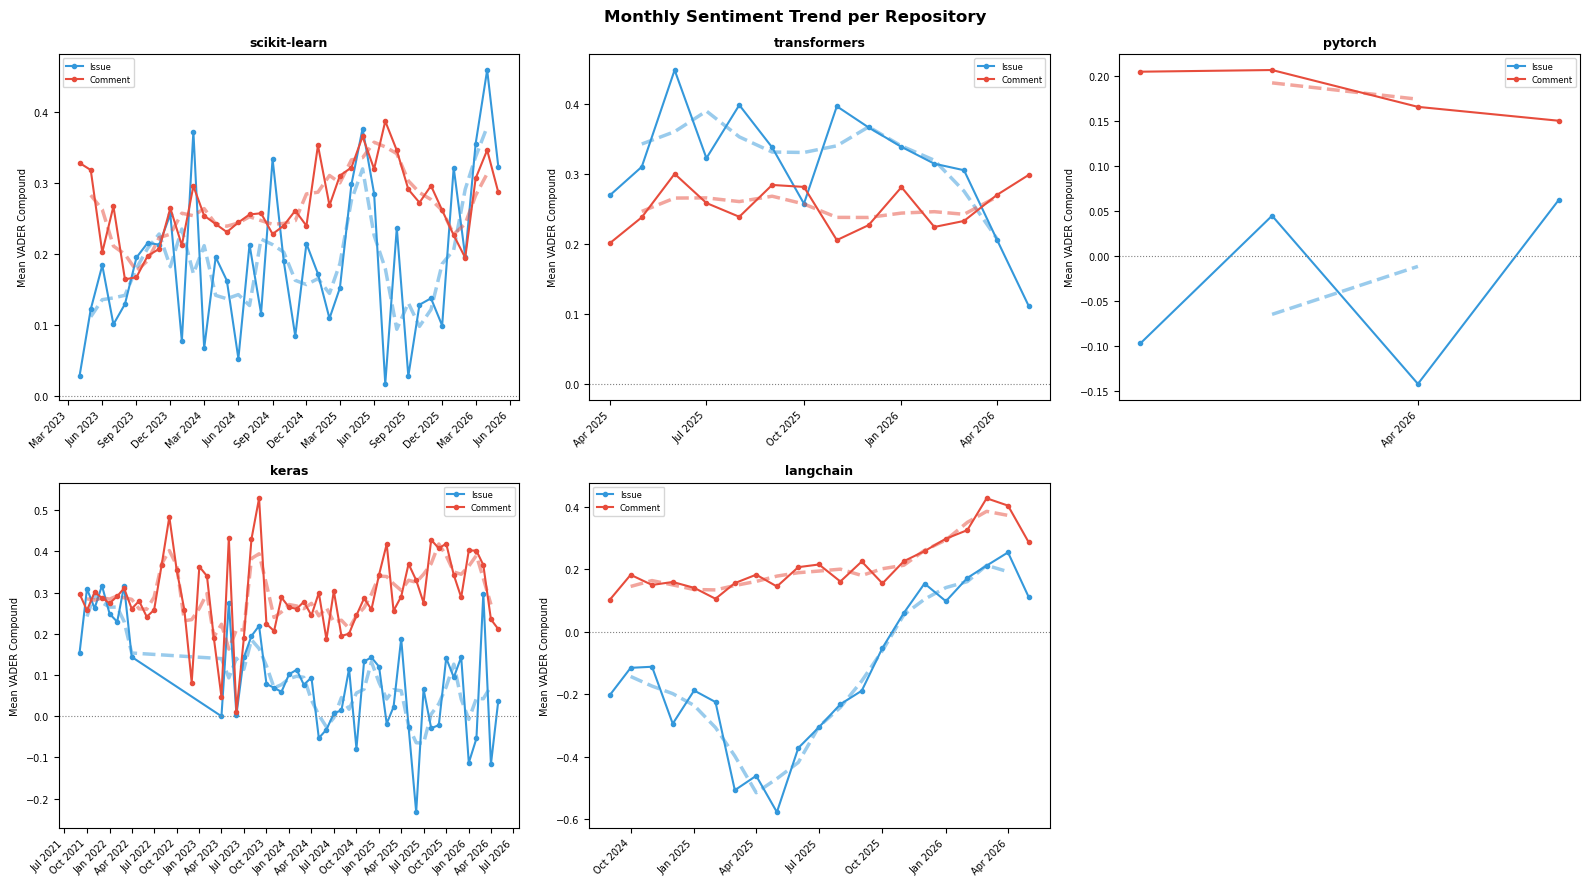

Saved → outputs/figures/sentiment_temporal_trend.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, repo in enumerate(REPOS):
    df  = all_sentiment[repo].copy()
    ax  = axes[i]

    df = df.dropna(subset=["created_at", "vader_compound"])
    df["month"] = df["created_at"].dt.to_period("M").dt.to_timestamp()

    monthly = (df.groupby(["month", "type"])["vader_compound"]
                 .mean()
                 .reset_index())

    for label, color in [("issue", "#3498db"), ("comment", "#e74c3c")]:
        subset = monthly[monthly["type"] == label].sort_values("month")
        if subset.empty:
            continue
        ax.plot(subset["month"], subset["vader_compound"],
                label=label.capitalize(), color=color, linewidth=1.5, marker="o", markersize=3)
        # Rolling 3-month smoothing
        if len(subset) >= 3:
            smoothed = subset["vader_compound"].rolling(3, center=True).mean()
            ax.plot(subset["month"], smoothed,
                    color=color, linewidth=2.5, alpha=0.5, linestyle="--")

    ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right", fontsize=6)
    ax.set_title(repo.split("/")[1], fontsize=9, fontweight="bold")
    ax.set_ylabel("Mean VADER Compound", fontsize=7)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)

axes[-1].set_visible(False)
plt.suptitle("Monthly Sentiment Trend per Repository",
             fontsize=12, fontweight="bold")
plt.tight_layout()
trend_path = f"{FIGURES_DIR}/sentiment_temporal_trend.png"
plt.savefig(trend_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {trend_path}")

## Cell 9 — BERTopic Topic Modelling (SC4)

In [8]:
print("Loading sentence-transformers model (all-MiniLM-L6-v2)...")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded.\n")

MIN_TOPIC_SIZE = 15   # minimum docs per topic — lower = more topics

for repo in REPOS:
    safe = SAFE_NAMES[repo]
    df   = all_sentiment[repo].copy()

    # Use clean_text; drop empties; cap at 5000 docs for speed
    docs = df["clean_text"].fillna("").replace("", np.nan).dropna().tolist()
    if len(docs) > 5000:
        docs = docs[:5000]

    print(f"{'='*55}")
    print(f"  {repo}  ({len(docs):,} documents)")
    print(f"{'='*55}")

    vectorizer = CountVectorizer(
        stop_words="english",
        min_df=3,
        max_df=0.90,
        ngram_range=(1, 2),
    )

    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer,
        min_topic_size=MIN_TOPIC_SIZE,
        nr_topics="auto",
        verbose=False,
    )

    topics, probs = topic_model.fit_transform(docs)

    topic_info = topic_model.get_topic_info()
    n_topics   = len(topic_info[topic_info["Topic"] != -1])
    outlier_pct = round((sum(t == -1 for t in topics) / len(topics)) * 100, 1)

    print(f"  Topics found: {n_topics}  |  Outlier docs: {outlier_pct}%")

    passed = n_topics >= 5
    sc_results.setdefault(repo, {})["sc4"] = passed
    print(f"  {'✅ SC4 passed' if passed else '⚠️ SC4 WARNING: fewer than 5 topics'}")

    # Print top 5 topics
    top5 = topic_info[topic_info["Topic"] != -1].head(5)
    for _, t_row in top5.iterrows():
        words = ", ".join([w for w, _ in topic_model.get_topic(t_row["Topic"])[:6]])
        print(f"    Topic {t_row['Topic']:>3} (n={t_row['Count']:>4}): {words}")

    # Save topic info
    topic_info_path = f"{TABLES_DIR}/{safe}_topic_info.csv"
    topic_info.to_csv(topic_info_path, index=False)
    print(f"  Saved topic info → {topic_info_path}")

    # Save topic assignments back to sentiment df (aligned by index in docs)
    # We used the first 5000 rows — assign -1 to the rest
    topic_col = pd.Series([-1] * len(df), index=df.index)
    doc_indices = df["clean_text"].fillna("").replace("", np.nan).dropna().index[:5000]
    topic_col.loc[doc_indices] = topics
    all_sentiment[repo]["topic"] = topic_col.values

    all_topics[repo] = (topic_model, topic_info)
    print()

print("✅ BERTopic complete for all repos.")

Loading sentence-transformers model (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded.

  scikit-learn/scikit-learn  (5,000 documents)
  Topics found: 43  |  Outlier docs: 38.4%
  ✅ SC4 passed
    Topic   0 (n= 616): array, scikit, scikit learn, learn, api, array api
    Topic   1 (n= 421): open, fix, hi, open source, bug, contribute
    Topic   2 (n= 286): label, prs, ai, issues, review, commit
    Topic   3 (n= 179): split, class, fold, classification, values, groups
    Topic   4 (n= 112): py, examples, image image, image, hi, referenced
  Saved topic info → outputs/tables/scikit-learn_scikit-learn_topic_info.csv

  huggingface/transformers  (5,000 documents)
  Topics found: 40  |  Outlier docs: 44.8%
  ✅ SC4 passed
    Topic   0 (n= 586): version, gpu, installed, task, scripts, using
    Topic   1 (n= 509): fixed, fix, closing, open, like claim, merged
    Topic   2 (n= 177): attention, model, implementation, models, encoder, vision
    Topic   3 (n= 146): transformers, library, transformers version, model, 44314, versions
    Topic   4 (n= 121): model,

## Cell 10 — Topic Word Cloud / Top-Words Bar Charts

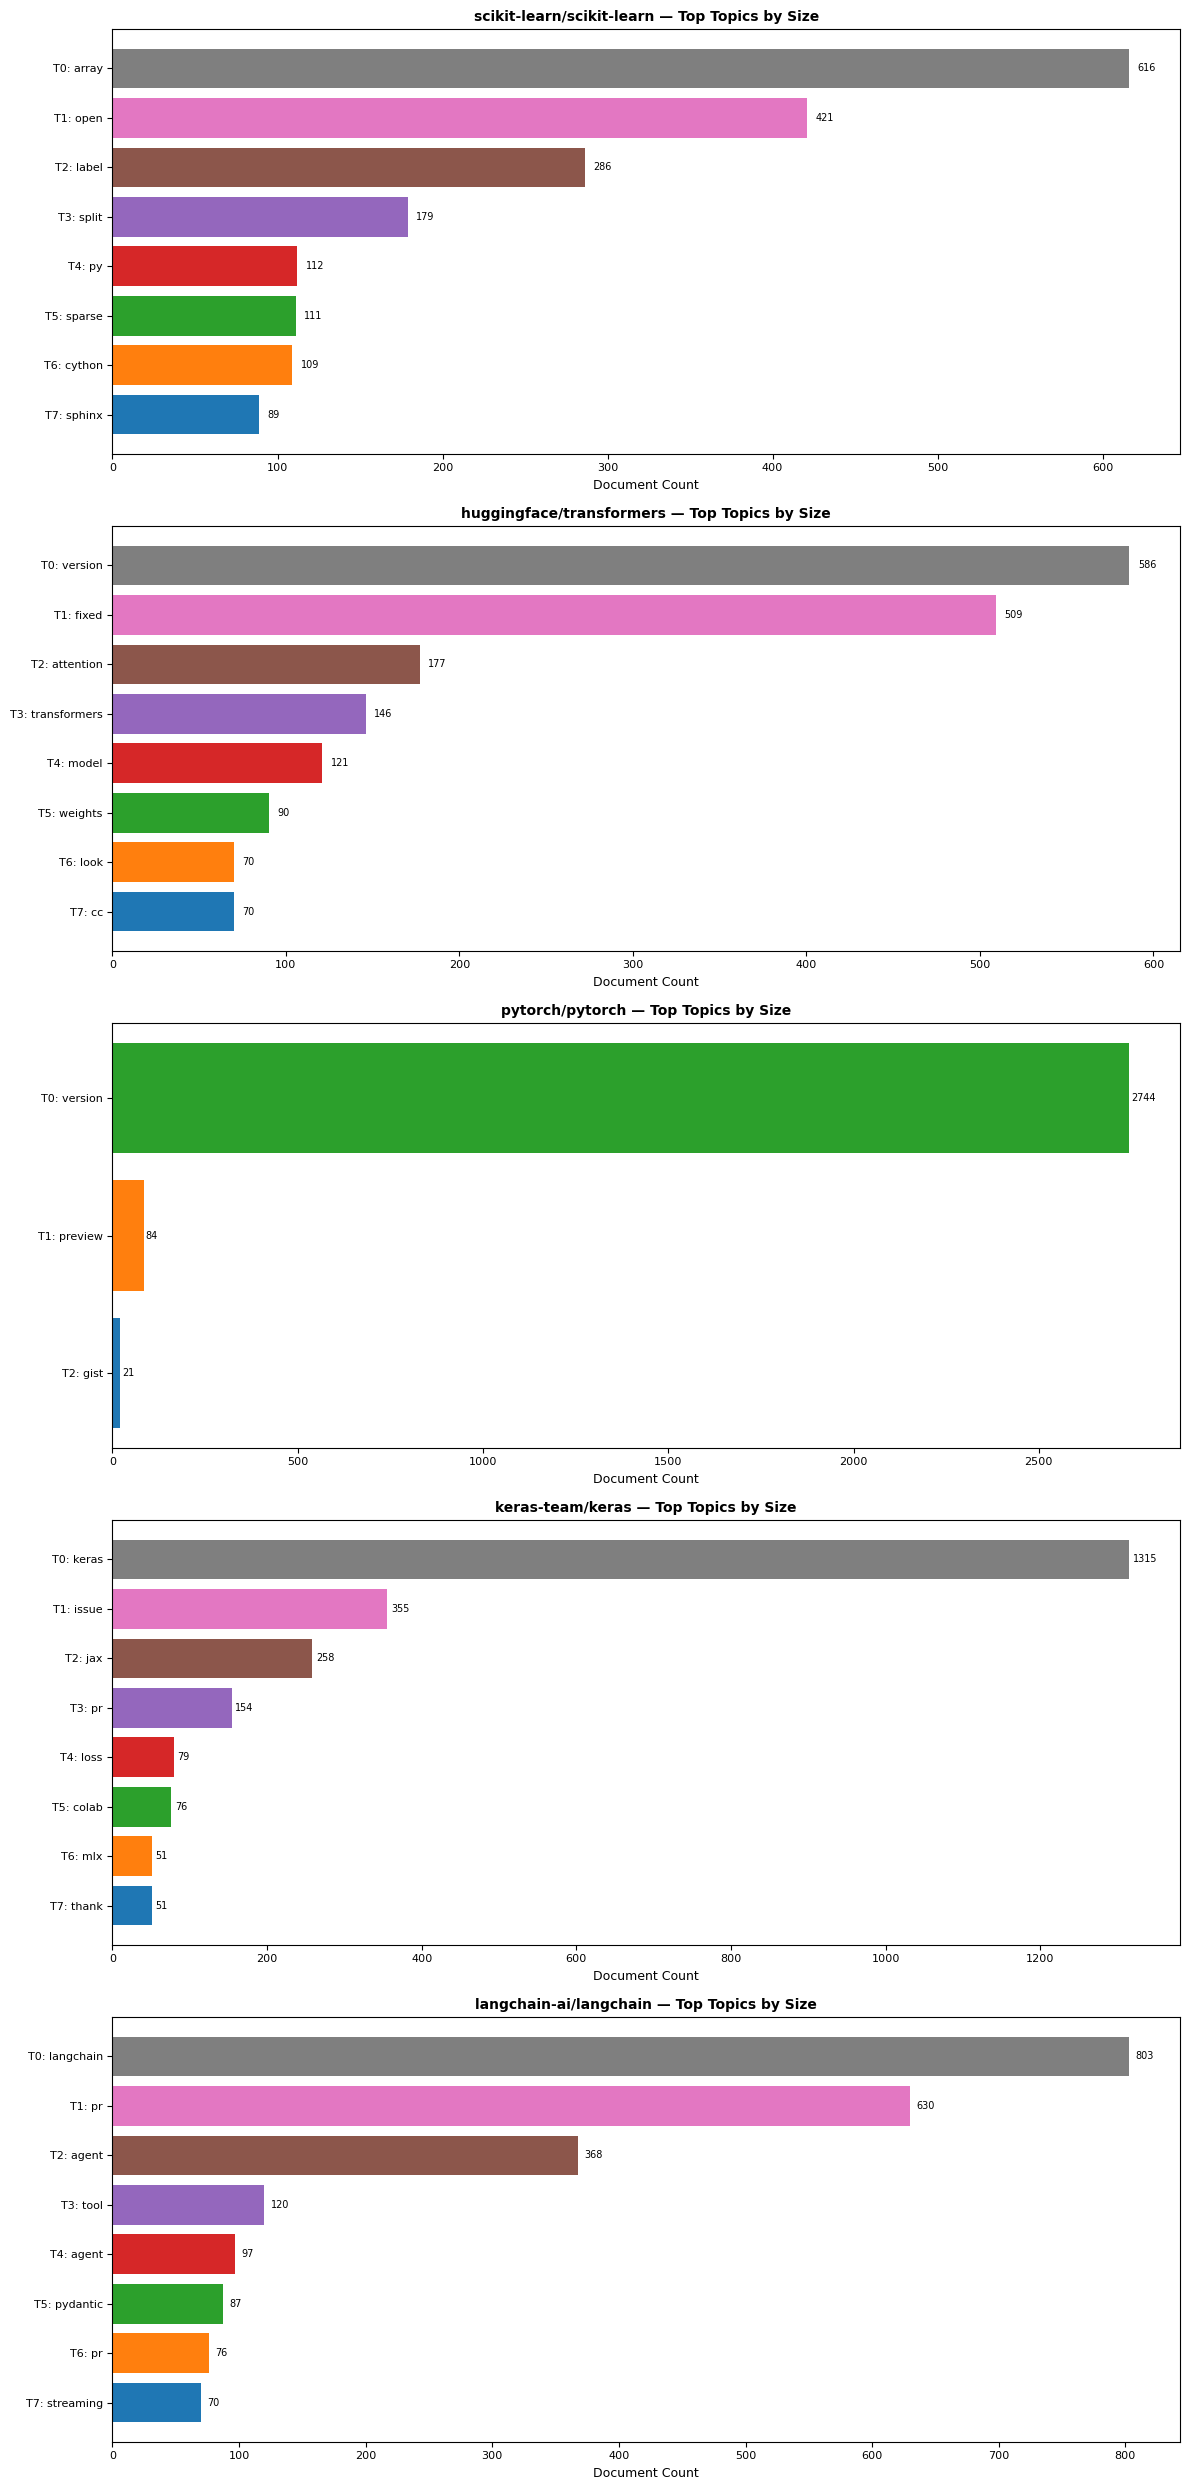

Saved → outputs/figures/topic_sizes.png


In [9]:
fig, axes = plt.subplots(len(REPOS), 1, figsize=(12, 5 * len(REPOS)))

for i, repo in enumerate(REPOS):
    ax = axes[i]
    topic_model, topic_info = all_topics[repo]
    safe = SAFE_NAMES[repo]

    # Top 8 topics by document count
    top_topics = topic_info[topic_info["Topic"] != -1].head(8)

    labels, values = [], []
    for _, t_row in top_topics.iterrows():
        top_word = topic_model.get_topic(t_row["Topic"])[0][0]
        labels.append(f"T{t_row['Topic']}: {top_word}")
        values.append(t_row["Count"])

    bars = ax.barh(labels[::-1], values[::-1],
                   color=sns.color_palette("tab10", len(labels)))
    ax.set_xlabel("Document Count", fontsize=9)
    ax.set_title(f"{repo} — Top Topics by Size", fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=8)

    for bar, val in zip(bars, values[::-1]):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                str(val), va="center", fontsize=7)

plt.tight_layout()
topics_path = f"{FIGURES_DIR}/topic_sizes.png"
plt.savefig(topics_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {topics_path}")

## Cell 11 — Spearman Correlation: Centrality vs Sentiment (SC6)

In [10]:
from scipy.stats import spearmanr

print("── SC6: Spearman Correlation — Centrality vs Mean Sentiment ──\n")

spearman_rows = []

for repo in REPOS:
    df_sent = all_sentiment[repo].copy()
    cent_df = all_centrality[repo].copy()

    # Compute mean sentiment per user across all their posts
    user_sentiment = (df_sent.groupby("author")["vader_compound"]
                              .agg(mean_sentiment="mean", n_posts="count")
                              .reset_index()
                              .rename(columns={"author": "user"}))

    # Merge with centrality
    merged = cent_df.merge(user_sentiment, on="user", how="inner")
    merged = merged[merged["n_posts"] >= 3]   # minimum 3 posts for stable estimate

    if len(merged) < 10:
        print(f"  {repo}: insufficient overlap ({len(merged)} users) — skipping")
        continue

    # Spearman on PageRank vs mean sentiment
    rho_pr, p_pr = spearmanr(merged["pagerank"], merged["mean_sentiment"])
    # Also test composite score
    rho_comp, p_comp = spearmanr(merged["composite"], merged["mean_sentiment"])

    passed = p_pr < 0.05
    sc_results.setdefault(repo, {})["sc6"] = passed

    spearman_rows.append({
        "repo":                repo,
        "n_users":             len(merged),
        "rho_pagerank":        round(rho_pr, 4),
        "p_pagerank":          round(p_pr, 6),
        "rho_composite":       round(rho_comp, 4),
        "p_composite":         round(p_comp, 6),
        "sc6_pass":            passed,
    })

    status = "✅ SC6 passed" if passed else "⚠️ SC6 not significant"
    print(f"  {repo}  (n={len(merged)} users)")
    print(f"    PageRank  ρ={rho_pr:.4f}, p={p_pr:.6f}")
    print(f"    Composite ρ={rho_comp:.4f}, p={p_comp:.6f}")
    print(f"    → {status}\n")

    # Save merged data for scatter plot
    merged_path = f"{TABLES_DIR}/{SAFE_NAMES[repo]}_centrality_sentiment.csv"
    merged.to_csv(merged_path, index=False)

spearman_df = pd.DataFrame(spearman_rows)
spearman_path = f"{TABLES_DIR}/spearman_results.csv"
spearman_df.to_csv(spearman_path, index=False)
print(f"Saved Spearman results → {spearman_path}")
print(spearman_df[["repo", "n_users", "rho_pagerank", "p_pagerank", "sc6_pass"]].to_string(index=False))

── SC6: Spearman Correlation — Centrality vs Mean Sentiment ──

  scikit-learn/scikit-learn  (n=421 users)
    PageRank  ρ=-0.0613, p=0.209085
    Composite ρ=-0.0517, p=0.290304
    → ⚠️ SC6 not significant

  huggingface/transformers  (n=517 users)
    PageRank  ρ=-0.0319, p=0.469851
    Composite ρ=-0.0432, p=0.326985
    → ⚠️ SC6 not significant

  pytorch/pytorch  (n=281 users)
    PageRank  ρ=-0.1198, p=0.044875
    Composite ρ=-0.1407, p=0.018256
    → ✅ SC6 passed

  keras-team/keras  (n=485 users)
    PageRank  ρ=-0.0811, p=0.074525
    Composite ρ=-0.1009, p=0.026345
    → ⚠️ SC6 not significant

  langchain-ai/langchain  (n=412 users)
    PageRank  ρ=-0.2207, p=0.000006
    Composite ρ=-0.2365, p=0.000001
    → ✅ SC6 passed

Saved Spearman results → outputs/tables/spearman_results.csv
                     repo  n_users  rho_pagerank  p_pagerank  sc6_pass
scikit-learn/scikit-learn      421       -0.0613    0.209085     False
 huggingface/transformers      517       -0.0319   

## Cell 12 — Scatter Plot: Centrality vs Sentiment

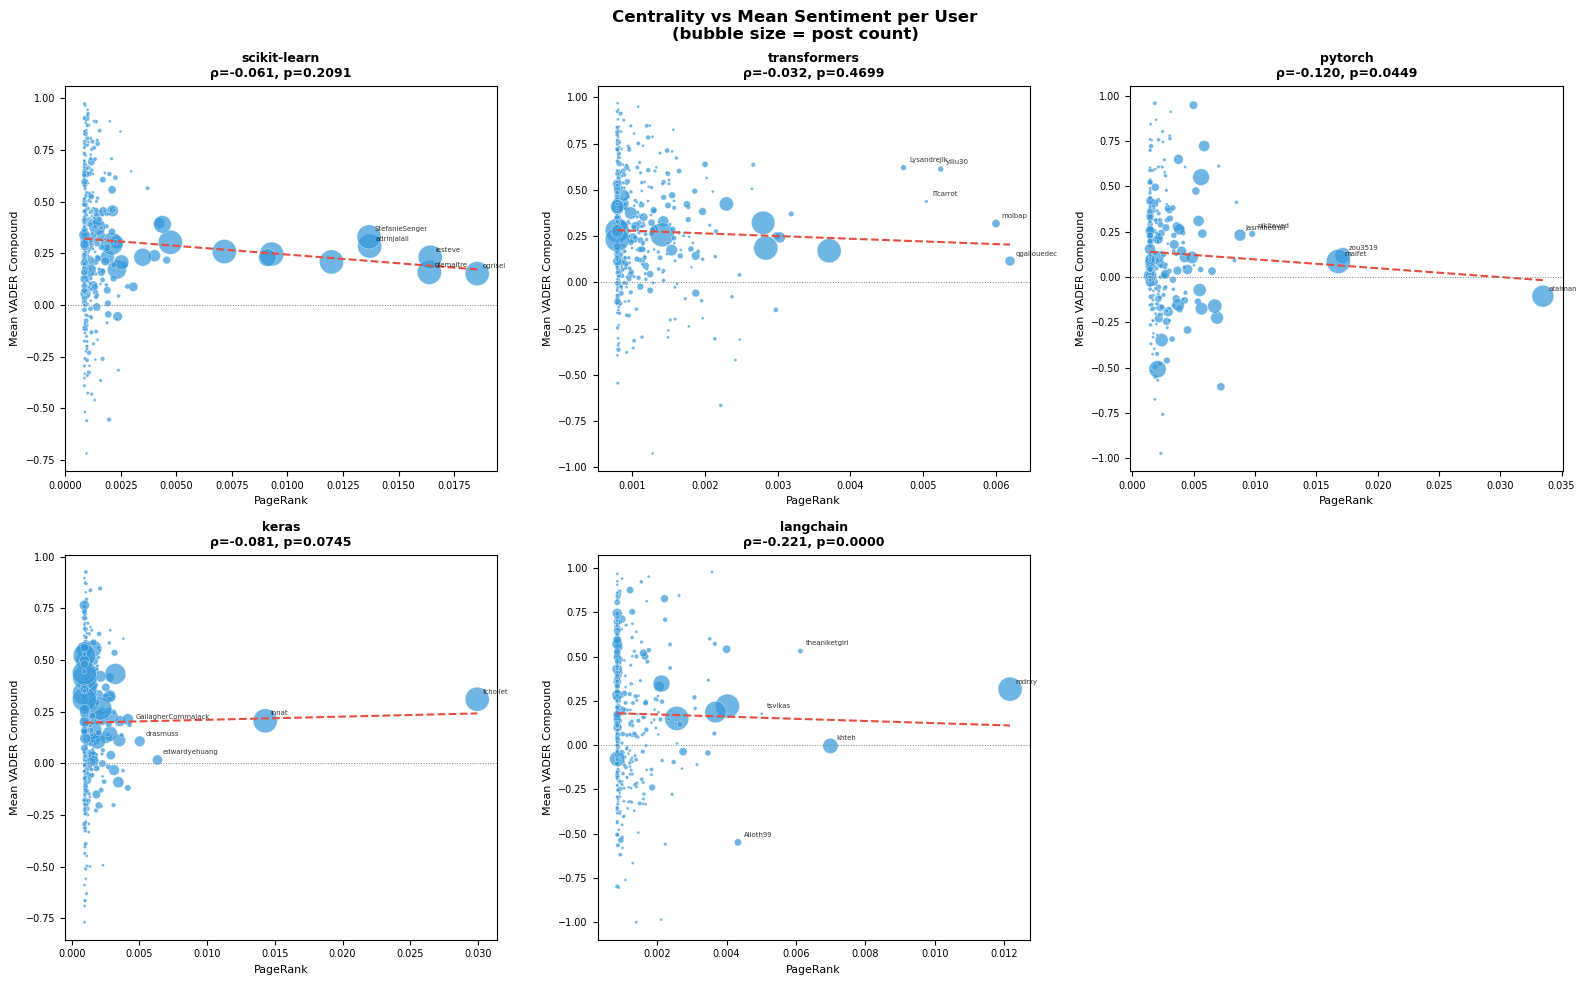

Saved → outputs/figures/centrality_vs_sentiment.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, repo in enumerate(REPOS):
    ax   = axes[i]
    safe = SAFE_NAMES[repo]

    merged_path = f"{TABLES_DIR}/{safe}_centrality_sentiment.csv"
    if not os.path.exists(merged_path):
        ax.set_visible(False)
        continue

    merged = pd.read_csv(merged_path)
    if merged.empty:
        ax.set_visible(False)
        continue

    # Colour by community if available
    if "community" in merged.columns:
        communities = merged["community"].astype("category").cat.codes
        scatter = ax.scatter(merged["pagerank"], merged["mean_sentiment"],
                             c=communities, cmap="tab20",
                             alpha=0.7, s=merged["n_posts"].clip(upper=200) * 1.5,
                             edgecolors="white", linewidths=0.3)
    else:
        scatter = ax.scatter(merged["pagerank"], merged["mean_sentiment"],
                             alpha=0.7, s=merged["n_posts"].clip(upper=200) * 1.5,
                             color="#3498db", edgecolors="white", linewidths=0.3)

    # Trend line
    if len(merged) >= 5:
        z = np.polyfit(merged["pagerank"], merged["mean_sentiment"], 1)
        p_line = np.poly1d(z)
        x_range = np.linspace(merged["pagerank"].min(), merged["pagerank"].max(), 100)
        ax.plot(x_range, p_line(x_range), color="#e74c3c", linewidth=1.5,
                linestyle="--", label="Trend")

    # Annotate top-5 by PageRank
    top5 = merged.nlargest(5, "pagerank")
    for _, r in top5.iterrows():
        ax.annotate(r["user"], (r["pagerank"], r["mean_sentiment"]),
                    fontsize=5, alpha=0.8,
                    xytext=(4, 4), textcoords="offset points")

    # Pull Spearman result if available
    rho_label = ""
    if not spearman_df.empty:
        row = spearman_df[spearman_df["repo"] == repo]
        if not row.empty:
            rho_label = f"ρ={row['rho_pagerank'].values[0]:.3f}, p={row['p_pagerank'].values[0]:.4f}"

    ax.set_title(f"{repo.split('/')[1]}\n{rho_label}", fontsize=9, fontweight="bold")
    ax.set_xlabel("PageRank", fontsize=8)
    ax.set_ylabel("Mean VADER Compound", fontsize=8)
    ax.axhline(0, color="grey", linewidth=0.7, linestyle=":")
    ax.tick_params(labelsize=7)

axes[-1].set_visible(False)
plt.suptitle("Centrality vs Mean Sentiment per User\n(bubble size = post count)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
scatter_path = f"{FIGURES_DIR}/centrality_vs_sentiment.png"
plt.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {scatter_path}")

## Cell 13 — Cross-Repo Sentiment Summary Table

In [12]:
print("── Cross-Repo Sentiment Summary ──\n")

summary_rows = []
for repo in REPOS:
    df = all_sentiment[repo]

    issues   = df[df["type"] == "issue"]["vader_compound"]
    comments = df[df["type"] == "comment"]["vader_compound"]
    all_rows = df["vader_compound"]

    topic_model, topic_info = all_topics.get(repo, (None, None))
    n_topics = len(topic_info[topic_info["Topic"] != -1]) if topic_info is not None else 0

    summary_rows.append({
        "repo":              repo,
        "mean_all":          round(all_rows.mean(), 4),
        "mean_issues":       round(issues.mean(), 4),
        "mean_comments":     round(comments.mean(), 4),
        "pct_positive":      round((all_rows > 0.05).mean() * 100, 1),
        "pct_negative":      round((all_rows < -0.05).mean() * 100, 1),
        "n_topics":          n_topics,
        "sc4_pass":          n_topics >= 5,
        "sc5_pass":          sc_results.get(repo, {}).get("sc5", False),
        "sc6_pass":          sc_results.get(repo, {}).get("sc6", False),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

summary_path = f"{TABLES_DIR}/nlp_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"\nSaved → {summary_path}")

── Cross-Repo Sentiment Summary ──

                     repo  mean_all  mean_issues  mean_comments  pct_positive  pct_negative  n_topics  sc4_pass  sc5_pass  sc6_pass
scikit-learn/scikit-learn    0.2528       0.1851         0.2649          59.8          21.8        43      True      True     False
 huggingface/transformers    0.2678       0.3257         0.2515          61.2          21.6        40      True      True     False
          pytorch/pytorch    0.1065      -0.0428         0.1844          47.2          32.4         3     False      True      True
         keras-team/keras    0.2490       0.1049         0.2882          61.2          22.9        27      True      True     False
   langchain-ai/langchain    0.1703      -0.0861         0.2605          55.0          29.3        38      True      True      True

Saved → outputs/tables/nlp_summary.csv


## Cell 14 — Final Output Check

In [13]:
print("=" * 60)
print("NOTEBOOK 4 — FINAL OUTPUT VERIFICATION")
print("=" * 60)

checks = {
    "mannwhitney_results.csv": f"{TABLES_DIR}/mannwhitney_results.csv",
    "spearman_results.csv":    f"{TABLES_DIR}/spearman_results.csv",
    "nlp_summary.csv":         f"{TABLES_DIR}/nlp_summary.csv",
    "sentiment_distribution.png":   f"{FIGURES_DIR}/sentiment_distribution.png",
    "sentiment_temporal_trend.png": f"{FIGURES_DIR}/sentiment_temporal_trend.png",
    "topic_sizes.png":              f"{FIGURES_DIR}/topic_sizes.png",
    "centrality_vs_sentiment.png":  f"{FIGURES_DIR}/centrality_vs_sentiment.png",
}
for repo in REPOS:
    safe = SAFE_NAMES[repo]
    checks[f"{safe}_sentiment.csv"]              = f"{PROCESSED_DIR}/{safe}_sentiment.csv"
    checks[f"{safe}_topic_info.csv"]             = f"{TABLES_DIR}/{safe}_topic_info.csv"
    checks[f"{safe}_centrality_sentiment.csv"]   = f"{TABLES_DIR}/{safe}_centrality_sentiment.csv"

all_ok = True
for name, path in checks.items():
    exists = os.path.isfile(path)
    status = "✅" if exists else "❌ MISSING"
    print(f"  {status}  {name}")
    if not exists:
        all_ok = False

print()
print("── Success Criteria ──")
for repo in REPOS:
    r = sc_results.get(repo, {})
    print(f"  {repo}")
    print(f"    SC4 (≥5 topics):           {'✅' if r.get('sc4') else '❌'}")
    print(f"    SC5 (open/closed p<0.05):  {'✅' if r.get('sc5') else '❌'}")
    print(f"    SC6 (centrality-sentiment):{'✅' if r.get('sc6') else '❌'}")

print()
if all_ok:
    print("🎉 All outputs present. Ready for report writing.")
else:
    print("⚠️  Some outputs missing — check errors above.")

NOTEBOOK 4 — FINAL OUTPUT VERIFICATION
  ✅  mannwhitney_results.csv
  ✅  spearman_results.csv
  ✅  nlp_summary.csv
  ✅  sentiment_distribution.png
  ✅  sentiment_temporal_trend.png
  ✅  topic_sizes.png
  ✅  centrality_vs_sentiment.png
  ✅  scikit-learn_scikit-learn_sentiment.csv
  ✅  scikit-learn_scikit-learn_topic_info.csv
  ✅  scikit-learn_scikit-learn_centrality_sentiment.csv
  ✅  huggingface_transformers_sentiment.csv
  ✅  huggingface_transformers_topic_info.csv
  ✅  huggingface_transformers_centrality_sentiment.csv
  ✅  pytorch_pytorch_sentiment.csv
  ✅  pytorch_pytorch_topic_info.csv
  ✅  pytorch_pytorch_centrality_sentiment.csv
  ✅  keras-team_keras_sentiment.csv
  ✅  keras-team_keras_topic_info.csv
  ✅  keras-team_keras_centrality_sentiment.csv
  ✅  langchain-ai_langchain_sentiment.csv
  ✅  langchain-ai_langchain_topic_info.csv
  ✅  langchain-ai_langchain_centrality_sentiment.csv

── Success Criteria ──
  scikit-learn/scikit-learn
    SC4 (≥5 topics):           ✅
    SC5 (open/